# Ekspor YOLOv8s dan YOLO26s-Pose ke ONNX untuk Jetson

Notebook ini khusus menyiapkan dua model YOLO yang menjadi beban terbesar pada pipeline HAR UAV:

1. `yolov8s.pt` sebagai detector manusia;
2. `yolo26s-pose.pt` sebagai estimator pose COCO17.

Model CNN-BiLSTM HAR yang sudah berbentuk ONNX **tidak diekspor ulang**. Keluaran notebook ini adalah ONNX FP32 portabel. TensorRT FP16 final harus dibangun kembali pada Jetson target karena file `.engine` bergantung pada arsitektur GPU dan versi TensorRT.

> Sebelum menjalankan: aktifkan GPU Kaggle. Jika Internet dinonaktifkan, tambahkan kedua file `.pt` melalui **Add Input**.

In [1]:
# Instalasi dependensi ekspor dan validasi
!pip install -q -U ultralytics onnx onnxruntime-gpu onnxslim

print("Instalasi selesai. Jika muncul peringatan konflik yang tidak menghentikan cell, lanjutkan.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 688.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.8/249.8 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.7/238.7 kB 13.2 MB/s eta 0:00:00
Instalasi selesai. Jika muncul peringatan konflik yang tidak menghentikan cell, lanjutkan.


In [2]:
# Import dan pemeriksaan lingkungan
import gc
import hashlib
import json
import os
import platform
import shutil
import subprocess
import time
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import onnx
import onnxruntime as ort
import pandas as pd
import torch
import ultralytics
from ultralytics import YOLO

warnings.filterwarnings("ignore")

print("Python       :", platform.python_version())
print("PyTorch      :", torch.__version__)
print("CUDA aktif   :", torch.cuda.is_available())
print("GPU          :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Ultralytics  :", ultralytics.__version__)
print("ONNX         :", onnx.__version__)
print("ONNX Runtime :", ort.__version__)
print("ORT providers:", ort.get_available_providers())

assert torch.cuda.is_available(), "Aktifkan GPU pada Settings > Accelerator > GPU."

# PT menggunakan GPU T4. Validasi ONNX sengaja menggunakan CPU agar tidak gagal
# ketika wheel ONNX Runtime Kaggle tidak kompatibel dengan CUDA runtime image.
PT_DEVICE = 0
ONNX_DEVICE = "cpu"
print("PT validation device  :", PT_DEVICE)
print("ONNX validation device:", ONNX_DEVICE)


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Python       : 3.12.13
PyTorch      : 2.10.0+cu128
CUDA aktif   : True
GPU          : Tesla T4
Ultralytics  : 8.4.115
ONNX         : 1.22.0
ONNX Runtime : 1.28.0
ORT providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
PT validation device  : 0
ONNX validation device: cpu


## Konfigurasi

Ukuran `512` dipilih sebagai titik awal Jetson Nano. ONNX tetap FP32 agar lebih portabel. Ketika dipindahkan ke Jetson, TensorRT akan membangun engine dengan mode FP16.

Jika nama modelmu berbeda, ubah `DETECTOR_NAME` dan `POSE_NAME`.

In [3]:
# ============================================================
# KONFIGURASI UTAMA
# ============================================================
DETECTOR_NAME = "yolov8s.pt"
POSE_NAME = "yolo26s-pose.pt"

EXPORT_IMGSZ = 512
EXPORT_BATCH = 1
EXPORT_OPSET = 17
EXPORT_DYNAMIC = False
EXPORT_SIMPLIFY = True

PERSON_CLASS_ID = 0
DETECTOR_CONF = 0.15
POSE_CONF = 0.05
BENCHMARK_WARMUP = 3
BENCHMARK_RUNS = 20

WORK_ROOT = Path("/kaggle/working/yolo_onnx_export")
MODEL_WORK_DIR = WORK_ROOT / "models"
OUTPUT_DIR = WORK_ROOT / "outputs"
PREVIEW_DIR = OUTPUT_DIR / "previews"

for directory in [MODEL_WORK_DIR, OUTPUT_DIR, PREVIEW_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Output root:", WORK_ROOT)


Output root: /kaggle/working/yolo_onnx_export


In [4]:
# Inventaris Kaggle Input
input_files = sorted(path for path in Path("/kaggle/input").rglob("*") if path.is_file())
print(f"Jumlah file input: {len(input_files):,}")

for path in input_files[:200]:
    print(path)

if len(input_files) > 200:
    print(f"... {len(input_files) - 200:,} file lain tidak ditampilkan")


Jumlah file input: 0


In [5]:
# Mencari model pada Kaggle Input; jika tidak ada, izinkan Ultralytics mengunduh
def find_exact_file(filename):
    candidates = sorted(Path("/kaggle/input").rglob(filename))
    if candidates:
        print(f"[FOUND] {filename}: {candidates[0]}")
        return candidates[0]
    print(f"[DOWNLOAD] {filename} tidak ditemukan di Kaggle Input.")
    print("           Ultralytics akan mencoba mengunduhnya. Internet Kaggle harus aktif.")
    return Path(filename)


def materialize_pt(requested_path, destination_dir):
    destination = destination_dir / requested_path.name
    if requested_path.is_file():
        shutil.copy2(requested_path, destination)
        return destination

    # Pemanggilan YOLO memicu unduhan model resmi jika Internet aktif.
    model = YOLO(str(requested_path))
    resolved = Path(model.ckpt_path) if getattr(model, "ckpt_path", None) else Path(requested_path.name)
    if not resolved.is_file():
        local_candidates = list(Path.cwd().rglob(requested_path.name))
        if not local_candidates:
            raise FileNotFoundError(
                f"{requested_path.name} gagal ditemukan/diunduh. "
                "Tambahkan file model melalui Add Input atau aktifkan Internet."
            )
        resolved = local_candidates[0]
    shutil.copy2(resolved, destination)
    return destination


detector_source = find_exact_file(DETECTOR_NAME)
pose_source = find_exact_file(POSE_NAME)

detector_pt = materialize_pt(detector_source, MODEL_WORK_DIR)
pose_pt = materialize_pt(pose_source, MODEL_WORK_DIR)

print("Detector working copy:", detector_pt, detector_pt.stat().st_size / 1e6, "MB")
print("Pose working copy    :", pose_pt, pose_pt.stat().st_size / 1e6, "MB")


[DOWNLOAD] yolov8s.pt tidak ditemukan di Kaggle Input.
           Ultralytics akan mencoba mengunduhnya. Internet Kaggle harus aktif.
[DOWNLOAD] yolo26s-pose.pt tidak ditemukan di Kaggle Input.
           Ultralytics akan mencoba mengunduhnya. Internet Kaggle harus aktif.
Detector working copy: /kaggle/working/yolo_onnx_export/models/yolov8s.pt 22.588772 MB
Pose working copy    : /kaggle/working/yolo_onnx_export/models/yolo26s-pose.pt 24.15179 MB


In [6]:
# Memastikan task kedua model benar sebelum ekspor
detector_pt_model = YOLO(str(detector_pt), task="detect")
pose_pt_model = YOLO(str(pose_pt), task="pose")

print("Detector task:", detector_pt_model.task)
print("Pose task    :", pose_pt_model.task)

assert detector_pt_model.task == "detect", f"Model detector salah task: {detector_pt_model.task}"
assert pose_pt_model.task == "pose", f"Model pose salah task: {pose_pt_model.task}"


Detector task: detect
Pose task    : pose


## Ekspor ONNX

Ekspor dilakukan dari salinan model di `/kaggle/working`, bukan langsung dari `/kaggle/input` yang bersifat *read-only*.

In [7]:
def export_onnx(model_path, task, output_name):
    print("=" * 80)
    print("EXPORT:", model_path.name, "task=", task)
    print("=" * 80)
    model = YOLO(str(model_path), task=task)
    exported = model.export(
        format="onnx",
        imgsz=EXPORT_IMGSZ,
        batch=EXPORT_BATCH,
        dynamic=EXPORT_DYNAMIC,
        simplify=EXPORT_SIMPLIFY,
        opset=EXPORT_OPSET,
        half=False,       # FP32 portabel; TensorRT Jetson yang mengaktifkan FP16
        device=0,
    )
    exported = Path(exported)
    final_path = OUTPUT_DIR / output_name
    shutil.copy2(exported, final_path)
    assert final_path.is_file() and final_path.stat().st_size > 0
    return final_path


detector_onnx = export_onnx(
    detector_pt,
    task="detect",
    output_name=f"yolov8s_{EXPORT_IMGSZ}_fp32.onnx",
)

gc.collect()
torch.cuda.empty_cache()

pose_onnx = export_onnx(
    pose_pt,
    task="pose",
    output_name=f"yolo26s-pose_{EXPORT_IMGSZ}_fp32.onnx",
)

print("Detector ONNX:", detector_onnx, detector_onnx.stat().st_size / 1e6, "MB")
print("Pose ONNX    :", pose_onnx, pose_onnx.stat().st_size / 1e6, "MB")


EXPORT: yolov8s.pt task= detect
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8s summary (fused): 72 layers, 11,156,544 parameters, 0 gradients, 18.3 GFLOPs

PyTorch: starting from '/kaggle/working/yolo_onnx_export/models/yolov8s.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 84, 5376) (21.5 MB)

ONNX: starting export with onnx 1.22.0 opset 17...
ONNX: slimming with onnxslim 0.1.95...
ONNX: export success ✅ 4.3s, saved as '/kaggle/working/yolo_onnx_export/models/yolov8s.onnx' (42.7 MB)

Export complete (5.7s)
Results saved to /kaggle/working/yolo_onnx_export/models/yolov8s.onnx
Predict:         yolo predict task=detect model=/kaggle/working/yolo_onnx_export/models/yolov8s.onnx imgsz=512 
Validat

In [8]:
# Pemeriksaan formal graph ONNX
def inspect_onnx(path):
    model = onnx.load(str(path))
    onnx.checker.check_model(model)

    def shape_of(value_info):
        dims = value_info.type.tensor_type.shape.dim
        return [dim.dim_value if dim.dim_value else dim.dim_param for dim in dims]

    info = {
        "filename": path.name,
        "size_mb": round(path.stat().st_size / 1e6, 3),
        "ir_version": model.ir_version,
        "opset": [item.version for item in model.opset_import],
        "inputs": [{"name": item.name, "shape": shape_of(item)} for item in model.graph.input],
        "outputs": [{"name": item.name, "shape": shape_of(item)} for item in model.graph.output],
        "nodes": len(model.graph.node),
        "checker": "PASS",
    }
    return info


detector_graph = inspect_onnx(detector_onnx)
pose_graph = inspect_onnx(pose_onnx)

print(json.dumps({"detector": detector_graph, "pose": pose_graph}, indent=2))


{
  "detector": {
    "filename": "yolov8s_512_fp32.onnx",
    "size_mb": 44.809,
    "ir_version": 8,
    "opset": [
      17
    ],
    "inputs": [
      {
        "name": "images",
        "shape": [
          1,
          3,
          512,
          512
        ]
      }
    ],
    "outputs": [
      {
        "name": "output0",
        "shape": [
          1,
          84,
          5376
        ]
      }
    ],
    "nodes": 233,
    "checker": "PASS"
  },
  "pose": {
    "filename": "yolo26s-pose_512_fp32.onnx",
    "size_mb": 41.762,
    "ir_version": 8,
    "opset": [
      17
    ],
    "inputs": [
      {
        "name": "images",
        "shape": [
          1,
          3,
          512,
          512
        ]
      }
    ],
    "outputs": [
      {
        "name": "output0",
        "shape": [
          1,
          300,
          57
        ]
      }
    ],
    "nodes": 417,
    "checker": "PASS"
  }
}


Sample fallback: /kaggle/working/yolo_onnx_export/bus.jpg


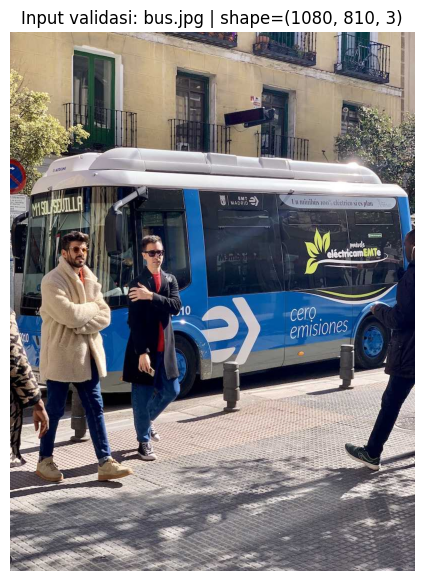

In [9]:
# Memilih gambar uji dari Kaggle Input atau mengambil frame pertama video
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
VIDEO_SUFFIXES = {".mp4", ".avi", ".mov", ".mkv", ".mpeg", ".mpg", ".m4v"}


def prepare_sample():
    images = [path for path in input_files if path.suffix.lower() in IMAGE_SUFFIXES]
    if images:
        image = cv2.imread(str(images[0]))
        if image is not None:
            output = WORK_ROOT / "sample_input.jpg"
            cv2.imwrite(str(output), image)
            print("Sample image:", images[0])
            return output

    videos = [path for path in input_files if path.suffix.lower() in VIDEO_SUFFIXES]
    for video in videos:
        capture = cv2.VideoCapture(str(video))
        ok, frame = capture.read()
        capture.release()
        if ok and frame is not None:
            output = WORK_ROOT / "sample_input.jpg"
            cv2.imwrite(str(output), frame)
            print("Sample frame dari:", video)
            return output

    # Fallback hanya berhasil bila Internet notebook aktif.
    fallback = WORK_ROOT / "bus.jpg"
    command = ["wget", "-q", "-O", str(fallback), "https://ultralytics.com/images/bus.jpg"]
    subprocess.run(command, check=False)
    if fallback.is_file() and fallback.stat().st_size > 0:
        print("Sample fallback:", fallback)
        return fallback

    raise FileNotFoundError(
        "Tidak ada gambar/video uji. Tambahkan minimal satu gambar atau video melalui Add Input."
    )


sample_path = prepare_sample()
sample_bgr = cv2.imread(str(sample_path))
assert sample_bgr is not None

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(sample_bgr, cv2.COLOR_BGR2RGB))
plt.title(f"Input validasi: {sample_path.name} | shape={sample_bgr.shape}")
plt.axis("off")
plt.show()


## Uji fungsi dan paritas `.pt` terhadap `.onnx`

Paritas ini membandingkan hasil pascaproses Ultralytics. Perbedaan kecil dapat terjadi akibat backend. Fokus utamanya adalah:

- detector ONNX tetap menghasilkan kelas manusia dan bounding box yang sebanding;
- pose ONNX tetap menghasilkan 17 keypoint COCO;
- tidak ada NaN/Inf;
- visualisasi masih masuk akal.

In [10]:
def predict(model, source, task, conf, device):
    return model.predict(
        source=str(source),
        imgsz=EXPORT_IMGSZ,
        conf=conf,
        iou=0.50,
        classes=[PERSON_CLASS_ID],
        max_det=20,
        device=device,
        verbose=False,
    )[0]


detector_onnx_model = YOLO(str(detector_onnx), task="detect")
pose_onnx_model = YOLO(str(pose_onnx), task="pose")

det_pt_result = predict(
    detector_pt_model, sample_path, "detect", DETECTOR_CONF, PT_DEVICE
)
det_onnx_result = predict(
    detector_onnx_model, sample_path, "detect", DETECTOR_CONF, ONNX_DEVICE
)
pose_pt_result = predict(
    pose_pt_model, sample_path, "pose", POSE_CONF, PT_DEVICE
)
pose_onnx_result = predict(
    pose_onnx_model, sample_path, "pose", POSE_CONF, ONNX_DEVICE
)


def detection_summary(result):
    if result.boxes is None or len(result.boxes) == 0:
        return {"count": 0, "boxes": np.empty((0, 4)), "conf": np.empty(0)}
    return {
        "count": len(result.boxes),
        "boxes": result.boxes.xyxy.detach().cpu().numpy().astype(np.float32),
        "conf": result.boxes.conf.detach().cpu().numpy().astype(np.float32),
    }


def box_iou_matrix(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.empty((len(a), len(b)), dtype=np.float32)
    lt = np.maximum(a[:, None, :2], b[None, :, :2])
    rb = np.minimum(a[:, None, 2:], b[None, :, 2:])
    wh = np.maximum(rb - lt, 0)
    intersection = wh[..., 0] * wh[..., 1]
    area_a = np.maximum(a[:, 2] - a[:, 0], 0) * np.maximum(a[:, 3] - a[:, 1], 0)
    area_b = np.maximum(b[:, 2] - b[:, 0], 0) * np.maximum(b[:, 3] - b[:, 1], 0)
    union = area_a[:, None] + area_b[None, :] - intersection
    return intersection / np.maximum(union, 1e-8)


det_pt = detection_summary(det_pt_result)
det_ox = detection_summary(det_onnx_result)
iou = box_iou_matrix(det_pt["boxes"], det_ox["boxes"])
best_ious = iou.max(axis=1) if iou.size else np.empty(0)

detector_parity = {
    "pt_count": det_pt["count"],
    "onnx_count": det_ox["count"],
    "mean_best_iou": float(best_ious.mean()) if best_ious.size else None,
    "min_best_iou": float(best_ious.min()) if best_ious.size else None,
    "pt_top_conf": float(det_pt["conf"].max()) if det_pt["conf"].size else None,
    "onnx_top_conf": float(det_ox["conf"].max()) if det_ox["conf"].size else None,
}


def pose_summary(result):
    if result.keypoints is None or len(result.keypoints.data) == 0:
        return {"people": 0, "shape": None, "keypoints": np.empty((0, 17, 3))}
    keypoints = result.keypoints.data.detach().cpu().numpy().astype(np.float32)
    assert keypoints.shape[1] == 17, f"Bukan COCO17: {keypoints.shape}"
    assert np.isfinite(keypoints).all(), "Keypoint mengandung NaN/Inf"
    return {"people": keypoints.shape[0], "shape": list(keypoints.shape), "keypoints": keypoints}


pose_pt = pose_summary(pose_pt_result)
pose_ox = pose_summary(pose_onnx_result)
min_people = min(pose_pt["people"], pose_ox["people"])

if min_people:
    # Perbandingan sederhana berdasarkan urutan confidence hasil pascaproses.
    pt_xy = pose_pt["keypoints"][:min_people, :, :2]
    ox_xy = pose_ox["keypoints"][:min_people, :, :2]
    image_diagonal = float(np.hypot(sample_bgr.shape[1], sample_bgr.shape[0]))
    normalized_keypoint_mae = float(np.abs(pt_xy - ox_xy).mean() / max(image_diagonal, 1.0))
else:
    normalized_keypoint_mae = None

pose_parity = {
    "pt_people": pose_pt["people"],
    "onnx_people": pose_ox["people"],
    "pt_shape": pose_pt["shape"],
    "onnx_shape": pose_ox["shape"],
    "normalized_keypoint_mae": normalized_keypoint_mae,
}

print("DETECTOR PARITY")
print(json.dumps(detector_parity, indent=2))
print("POSE PARITY")
print(json.dumps(pose_parity, indent=2))


Loading /kaggle/working/yolo_onnx_export/outputs/yolov8s_512_fp32.onnx for ONNX Runtime inference...
requirements: Ultralytics requirement ['onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 5 packages in 711ms
 Downloaded onnxruntime
Prepared 1 package in 938ms
Installed 1 package in 95ms
 + onnxruntime==1.28.0

requirements: AutoUpdate success ✅ 2.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Using ONNX Runtime 1.28.0 with CPUExecutionProvider
Loading /kaggle/working/yolo_onnx_export/outputs/yolo26s-pose_512_fp32.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.28.0 with CPUExecutionProvider
DETECTOR PARITY
{
  "pt_count": 4,
  "onnx_count": 4,
  "mean_best_iou": 0.9885421991348267,
  "min_best_iou": 0.9680972695350647,
  "pt_top_conf": 0.9023407697677612,
  "onnx_top_conf": 0.899798572063446
}
POSE PARITY
{
  "pt_people": 5,
  "onnx_people": 5,
  "pt_shape": [
    5,
    17,
    3
  

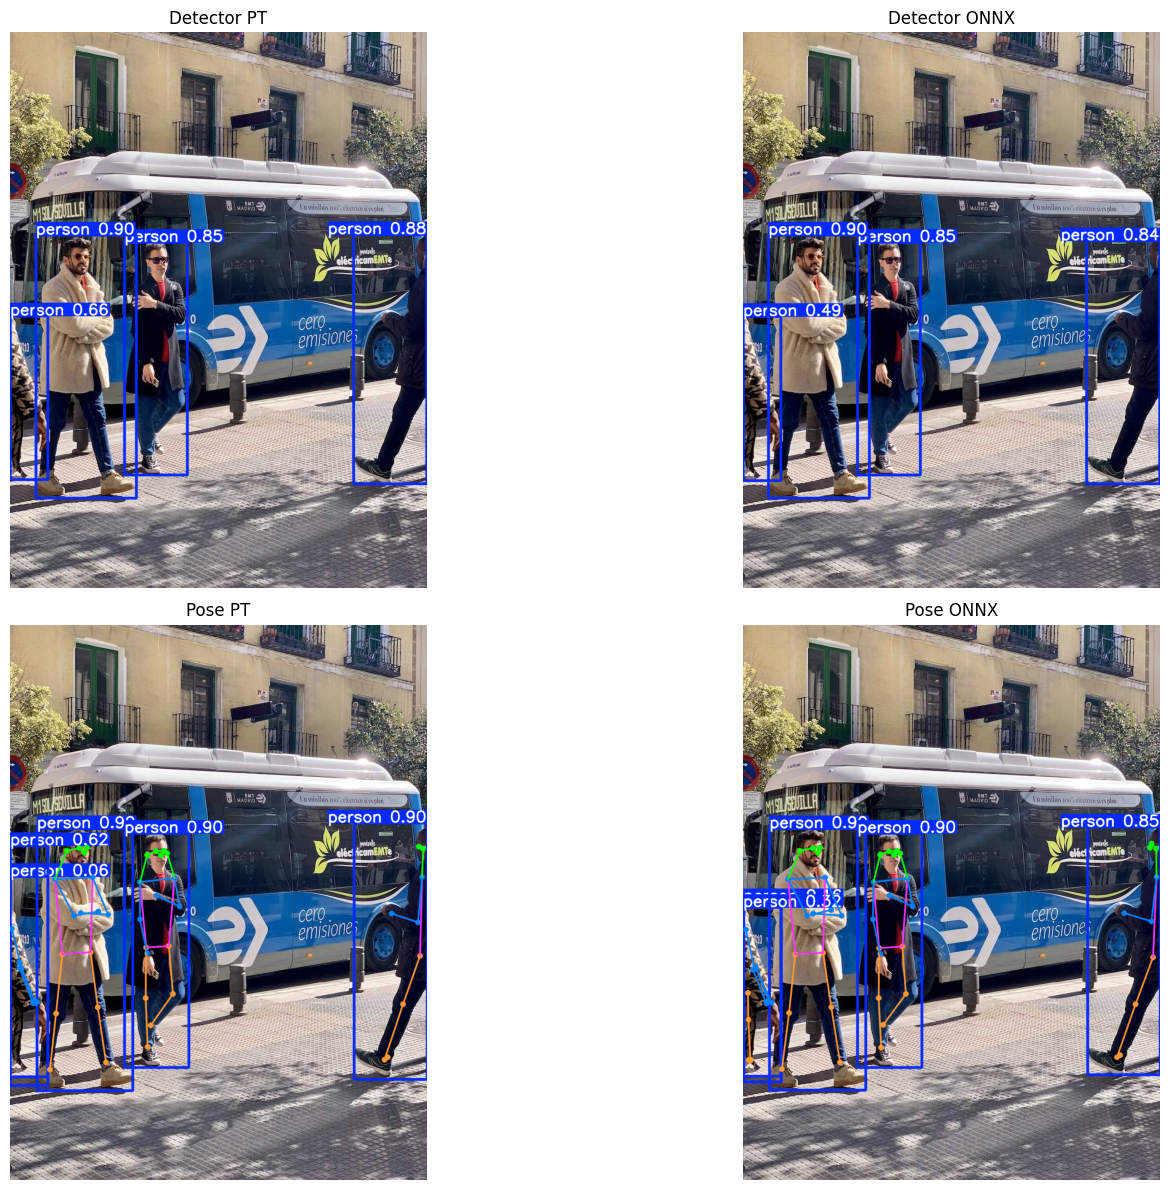

In [11]:
# Visualisasi empat hasil: detector PT/ONNX dan pose PT/ONNX
visuals = [
    ("Detector PT", det_pt_result.plot()),
    ("Detector ONNX", det_onnx_result.plot()),
    ("Pose PT", pose_pt_result.plot()),
    ("Pose ONNX", pose_onnx_result.plot()),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for axis, (title, image_bgr) in zip(axes.flat, visuals):
    axis.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    axis.set_title(title)
    axis.axis("off")
    cv2.imwrite(str(PREVIEW_DIR / f"{title.lower().replace(' ', '_')}.jpg"), image_bgr)
plt.tight_layout()
plt.show()


## Benchmark Kaggle

Model `.pt` diukur pada GPU T4, sedangkan ONNX diukur pada CPU untuk menghindari ketidakcocokan ONNX Runtime CUDA pada image Kaggle. Karena perangkat eksekusinya berbeda, angka ini **bukan perbandingan kecepatan PT versus ONNX** dan bukan FPS Jetson. Tujuannya adalah memastikan kedua backend dapat dijalankan tanpa error. Benchmark akselerasi final dilakukan dengan TensorRT FP16 di Jetson.

In [12]:
def synchronize():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def benchmark(model, task, conf, label, device):
    for _ in range(BENCHMARK_WARMUP):
        predict(model, sample_path, task, conf, device)
    synchronize()

    times_ms = []
    for _ in range(BENCHMARK_RUNS):
        synchronize()
        started = time.perf_counter()
        predict(model, sample_path, task, conf, device)
        synchronize()
        times_ms.append((time.perf_counter() - started) * 1000.0)

    values = np.asarray(times_ms, dtype=np.float64)
    return {
        "model": label,
        "device": str(device),
        "runs": BENCHMARK_RUNS,
        "mean_ms": float(values.mean()),
        "median_ms": float(np.median(values)),
        "p95_ms": float(np.percentile(values, 95)),
        "estimated_fps_single_model": float(1000.0 / values.mean()),
    }


benchmarks = [
    benchmark(detector_pt_model, "detect", DETECTOR_CONF, "detector_pt", PT_DEVICE),
    benchmark(detector_onnx_model, "detect", DETECTOR_CONF, "detector_onnx", ONNX_DEVICE),
    benchmark(pose_pt_model, "pose", POSE_CONF, "pose_pt", PT_DEVICE),
    benchmark(pose_onnx_model, "pose", POSE_CONF, "pose_onnx", ONNX_DEVICE),
]

benchmark_df = pd.DataFrame(benchmarks)
display(benchmark_df)
benchmark_df.to_csv(OUTPUT_DIR / "benchmark_kaggle.csv", index=False)


,model,device,runs,mean_ms,median_ms,p95_ms,estimated_fps_single_model
0,detector_pt,0,20,15.426874,15.473485,17.243356,64.821945
1,detector_onnx,cpu,20,189.309945,188.224540,199.978715,5.282343
2,pose_pt,0,20,18.195618,18.828742,19.958068,54.958287
3,pose_onnx,cpu,20,166.127454,165.793060,172.975300,6.019475


In [13]:
# Validasi akhir dan manifest artefak
def sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


validation = {
    "detector_onnx_checker": detector_graph["checker"],
    "pose_onnx_checker": pose_graph["checker"],
    "detector_has_output": det_ox["count"] > 0,
    "pose_has_output": pose_ox["people"] > 0,
    "pose_is_coco17": pose_ox["shape"] is not None and pose_ox["shape"][1] == 17,
    "detector_mean_best_iou_pass": (
        detector_parity["mean_best_iou"] is not None
        and detector_parity["mean_best_iou"] >= 0.90
    ),
    "pose_keypoint_mae_pass": (
        pose_parity["normalized_keypoint_mae"] is not None
        and pose_parity["normalized_keypoint_mae"] <= 0.02
    ),
}

manifest = {
    "purpose": "Portable ONNX export; build TensorRT FP16 again on target Jetson",
    "export": {
        "imgsz": EXPORT_IMGSZ,
        "batch": EXPORT_BATCH,
        "opset": EXPORT_OPSET,
        "dynamic": EXPORT_DYNAMIC,
        "onnx_precision": "FP32",
    },
    "files": {
        "detector": {
            "name": detector_onnx.name,
            "size_bytes": detector_onnx.stat().st_size,
            "sha256": sha256(detector_onnx),
        },
        "pose": {
            "name": pose_onnx.name,
            "size_bytes": pose_onnx.stat().st_size,
            "sha256": sha256(pose_onnx),
        },
    },
    "onnx_graph": {"detector": detector_graph, "pose": pose_graph},
    "parity": {"detector": detector_parity, "pose": pose_parity},
    "validation": validation,
    "benchmark_kaggle": benchmarks,
    "environment": {
        "gpu": torch.cuda.get_device_name(0),
        "torch": torch.__version__,
        "ultralytics": ultralytics.__version__,
        "onnx": onnx.__version__,
        "onnxruntime": ort.__version__,
        "providers": ort.get_available_providers(),
        "pt_validation_device": str(PT_DEVICE),
        "onnx_validation_device": str(ONNX_DEVICE),
    },
}

manifest_path = OUTPUT_DIR / "export_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

print(json.dumps(validation, indent=2))
if not all(validation.values()):
    print("PERINGATAN: Ada pemeriksaan yang belum lulus. Periksa visualisasi dan manifest sebelum deploy.")
else:
    print("SELURUH PEMERIKSAAN UTAMA LULUS.")


{
  "detector_onnx_checker": "PASS",
  "pose_onnx_checker": "PASS",
  "detector_has_output": true,
  "pose_has_output": true,
  "pose_is_coco17": true,
  "detector_mean_best_iou_pass": true,
  "pose_keypoint_mae_pass": true
}
SELURUH PEMERIKSAAN UTAMA LULUS.


In [14]:
# Membuat ZIP keluaran yang dapat diunduh dari panel Output Kaggle
README_TEXT = f'''YOLO ONNX EXPORT FOR JETSON
================================

Detector : {detector_onnx.name}
Pose     : {pose_onnx.name}
Input    : batch=1, imgsz={EXPORT_IMGSZ}, FP32 ONNX, opset={EXPORT_OPSET}

ONNX ini dibuat portabel. Jangan membuat TensorRT .engine final di Kaggle untuk
dipindahkan ke Jetson. Salin ONNX ke Jetson lalu build TensorRT FP16 di perangkat
target agar sesuai dengan GPU dan versi TensorRT Jetson.

CNN-BiLSTM HAR ONNX tidak termasuk karena model tersebut sudah diekspor dan
divalidasi secara terpisah.
'''

(OUTPUT_DIR / "README.txt").write_text(README_TEXT, encoding="utf-8")

zip_base = Path("/kaggle/working/yolo_detector_pose_onnx_512")
zip_path = Path(shutil.make_archive(str(zip_base), "zip", root_dir=OUTPUT_DIR))

print("=" * 80)
print("SELESAI")
print("Detector ONNX:", detector_onnx)
print("Pose ONNX    :", pose_onnx)
print("Manifest     :", manifest_path)
print("ZIP          :", zip_path)
print("=" * 80)
print("Klik Save Version agar output tersimpan, lalu unduh ZIP dari panel Output.")


SELESAI
Detector ONNX: /kaggle/working/yolo_onnx_export/outputs/yolov8s_512_fp32.onnx
Pose ONNX    : /kaggle/working/yolo_onnx_export/outputs/yolo26s-pose_512_fp32.onnx
Manifest     : /kaggle/working/yolo_onnx_export/outputs/export_manifest.json
ZIP          : /kaggle/working/yolo_detector_pose_onnx_512.zip
Klik Save Version agar output tersimpan, lalu unduh ZIP dari panel Output.


## Tahap berikutnya di Jetson

Setelah ZIP diunduh dan ONNX dipindahkan ke Jetson:

```bash
# Contoh dengan trtexec; lokasi executable mengikuti instalasi JetPack.
/usr/src/tensorrt/bin/trtexec \
  --onnx=yolov8s_512_fp32.onnx \
  --saveEngine=yolov8s_512_fp16.engine \
  --fp16 --workspace=2048

/usr/src/tensorrt/bin/trtexec \
  --onnx=yolo26s-pose_512_fp32.onnx \
  --saveEngine=yolo26s-pose_512_fp16.engine \
  --fp16 --workspace=2048
```

Jika konversi gagal karena operator atau versi opset, simpan log lengkapnya. Jangan mengganti arsitektur atau melatih ulang sebelum penyebab kompatibilitas diperiksa.